# CatBoost Experiments for ECG Classification

## Pipeline
1. Feature Engineering — новые признаки поверх базовых из `train_model.py`
2. Выбор лучших признаков (Feature Selection) по важности CatBoost
3. Сравнение подходов: **One Multiclass Model vs Per-Class Binary Models**
4. Обучение CatBoost с подбором гиперпараметров Optuna + кросс-валидация
5. Финальное обучение и оценка на test
6. Сравнение с базовой моделью LinearSVC

In [1]:
import sys
import warnings
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.signal import welch

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import label_binarize
from sklearn.calibration import CalibratedClassifierCV

from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, average_precision_score


from catboost import CatBoostClassifier, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

c:\Users\vasav\anaconda3\envs\final_project_start_ml_py311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# константы
DATA_PATH = '../datasets/clean_ptbxl_with_ecg_n_diagnostic_superclass.pkl'
SUPERCLASSES = ['CD', 'HYP', 'MI', 'NORM', 'STTC'] # согласно предыдущим экспериментам, эти классы наиболее информативные для классификации
SEED = 42

np.random.seed(SEED)

## 1. Data Loading & Preprocessing

Воспроизводим `preprocess()` из `train_model.py` без изменений.

In [3]:
def fill_rand_based_q(df, cols=['height', 'weight'], group='sex'):
    df = df.copy()
    np.random.seed(42)
    for col in cols:
        q = df.groupby(group)[col].quantile([0.1, 0.9]).unstack()
        for s in q.index:
            low, high = q.loc[s, 0.1], q.loc[s, 0.9]
            mask = (df[group] == s) & (df[col].isna())
            if pd.isna(low) or pd.isna(high) or low == high:
                continue
            df.loc[mask, col] = np.random.uniform(low, high, mask.sum())
    return df


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Предобработка данных (аналогично train_model.py)."""
    mapping = {'CD': 'C', 'HYP': 'H', 'MI': 'M', 'STTC': 'S'}

    def make_combo_class(row):
        letters = ''.join(mapping[col] for col in ['MI', 'HYP', 'CD', 'STTC'] if row[col] == 1)
        return 'N' if letters == '' else letters

    df = df.drop(['pacemaker', 'extra_beats', 'infarction_stadium1', 'infarction_stadium2'], axis=1)
    df = fill_rand_based_q(df)
    df['heart_axis'] = df.heart_axis.fillna('NO_DATA')
    df['age'] = df['age'].replace(300, 98)
    df = df[df['height'] >= 90]
    df = df[df['weight'] > 25]
    df = df[df['diagnostic_superclass'].apply(lambda x: len(x) > 0)]

    unique_classes = sorted({lbl for row in df['diagnostic_superclass'] for lbl in row})
    for lbl in unique_classes:
        df[lbl] = df['diagnostic_superclass'].apply(lambda x: int(lbl in x))

    final_columns = [
        'ecg_id', 'patient_id', 'recording_date', 'age', 'sex',
        'height', 'weight', 'heart_axis', 'ecg_signals',
        'CD', 'HYP', 'MI', 'NORM', 'STTC', 'diagnostic_superclass', 'strat_fold'
    ]
    df = df[final_columns]

    # убираем строки где NORM + другой диагноз (медицинское противоречие)
    mask_bad = (
        (df['NORM'] == 1) &
        ((df['CD'] == 1) | (df['HYP'] == 1) | (df['MI'] == 1) | (df['STTC'] == 1))
    )
    df = df.loc[~mask_bad].reset_index(drop=True)

    # создаем комбо-класс (16-классовая задача)
    df['combo_class'] = df.apply(make_combo_class, axis=1)
    df['combo_idx'], _ = pd.factorize(df['combo_class'])

    # OHE для heart_axis
    df = pd.get_dummies(df, columns=['heart_axis'], prefix='heart_axis')

    print(f'Dataset after preprocess: {df.shape}')
    print(f'Combo classes: {df["combo_class"].nunique()}')
    print(f'Removed bad NORM rows: {mask_bad.sum()}')
    return df


print('Preprocessing functions defined')

Preprocessing functions defined


In [4]:
raw_df = pd.read_pickle(r'C:\Users\vasav\Documents\GitHub\project_9_med_predict\experiments\datasets\clean_ptbxl_with_ecg_n_diagnostic_superclass.pkl')
print(f'Raw data: {raw_df.shape}')
df = preprocess(raw_df)

Raw data: (12766, 21)
Dataset after preprocess: (12311, 26)
Combo classes: 16
Removed bad NORM rows: 326


## 2. Feature Engineering

### 2.1 Базовые ECG-признаки (из `train_model.py`)
На каждый из 12 отведений (192 итого):
- Статистика: `mean`, `median`, `std`, `min`, `max`, `range`, `rms`
- Форма: `skew`, `kurtosis`
- Энергия: `energy`, `norm_energy`
- Частоты (Welch): `dom_freq`, `spec_entropy`, `lf_energy`, `hf_energy`, `lf_hf_ratio`

### 2.2 Новые признаки
- **BMI** = weight / (height/100)²
- На каждый lead: `p25`, `p75`, `iqr`, `mad`, `zero_crossing_rate`, `mean_abs_diff`, `autocorr1`, `coeff_variation`
- Производная: `mean_abs_deriv`, `std_deriv`, `max_abs_deriv`
- Межотводные корреляции: 6 физиологически значимых пар
- ECG-уровень: `global_energy_var`, `max_lead_range`, `mean_lead_std`

In [5]:
def extract_ecg_features(ecg: np.ndarray) -> dict:
    """Извлекает базовые + новые признаки из одной ECG записи (5000×12)."""
    features = {}
    num_leads = ecg.shape[1]
    all_stds = []
    all_ranges = []
    all_energies = []

    for lead_idx in range(num_leads):
        lead = ecg[:, lead_idx].astype(np.float64)
        p = f'lead{lead_idx + 1}'

        # --- Базовые статистики ---
        features[f'{p}_mean']= np.mean(lead)
        features[f'{p}_median'] = np.median(lead)
        features[f'{p}_std']    = np.std(lead)
        features[f'{p}_min']    = np.min(lead)
        features[f'{p}_max']    = np.max(lead)
        features[f'{p}_range']  = np.max(lead) - np.min(lead)
        features[f'{p}_rms']    = np.sqrt(np.mean(lead ** 2))

        # --- Форма распределения ---
        features[f'{p}_skew']   = float(skew(lead))
        features[f'{p}_kurt']   = float(kurtosis(lead))

        # --- Энергия ---
        energy = np.sum(lead ** 2)
        features[f'{p}_energy']      = energy
        features[f'{p}_norm_energy'] = energy / len(lead)

        # --- Частотные (Welch) ---
        freqs, psd = welch(lead, fs=500)
        psd_norm = psd / (np.sum(psd) + 1e-12)
        features[f'{p}_dom_freq']     = freqs[np.argmax(psd)]
        features[f'{p}_spec_entropy'] = float(-np.sum(psd_norm * np.log(psd_norm + 1e-12)))

        lf_mask = (freqs >= 0.04) & (freqs <= 0.15)
        hf_mask = (freqs >= 0.15) & (freqs <= 0.40)
        lf_e = np.sum(psd[lf_mask])
        hf_e = np.sum(psd[hf_mask])
        features[f'{p}_lf_energy']   = lf_e
        features[f'{p}_hf_energy']   = hf_e
        features[f'{p}_lf_hf_ratio'] = lf_e / (hf_e + 1e-6)

        # --- Новые признаки --- 
        # Квартили и IQR
        p25, p75 = np.percentile(lead, [25, 75])
        features[f'{p}_p25'] = p25
        features[f'{p}_p75'] = p75
        features[f'{p}_iqr'] = p75 - p25

        # MAD — среднее абсолютное отклонение (робастная дисперсия)
        features[f'{p}_mad'] = np.mean(np.abs(lead - np.mean(lead)))

        # Zero Crossing Rate — количество пересечений нуля (связано с ЧСС)
        signs = np.sign(lead)
        signs[signs == 0] = 1
        zcr = np.sum(np.diff(signs) != 0) / len(lead)
        features[f'{p}_zcr'] = zcr

        # Среднее абсолютное изменение (Mean Absolute First Difference)
        diff = np.diff(lead)
        features[f'{p}_mean_abs_diff'] = np.mean(np.abs(diff))
        features[f'{p}_std_diff']      = np.std(diff)
        features[f'{p}_max_abs_diff']  = np.max(np.abs(diff))

        # Автокорреляция с лагом 1 (степень «гладкости» сигнала)
        if np.std(lead) > 1e-6:
            features[f'{p}_autocorr1'] = np.corrcoef(lead[:-1], lead[1:])[0, 1]
        else:
            features[f'{p}_autocorr1'] = 0.0

        # Коэффициент вариации CV = std/|mean+eps|
        features[f'{p}_cv'] = np.std(lead) / (np.abs(np.mean(lead)) + 1e-6)

        # HF2 диапазон (0.4–2.0 Гц) — захватывает фундаментальную ЧСС 24–120 bpm
        hf2_mask = (freqs >= 0.4) & (freqs <= 2.0)
        features[f'{p}_hf2_energy'] = np.sum(psd[hf2_mask])

        # Доля LF энергии в суммарной (относительная мощность)
        total_e = np.sum(psd) + 1e-12
        features[f'{p}_lf_rel'] = lf_e / total_e
        features[f'{p}_hf_rel'] = hf_e / total_e

        all_stds.append(np.std(lead))
        all_ranges.append(np.max(lead) - np.min(lead))
        all_energies.append(energy)

    # --- Межотводные корреляции (6 физиологически значимых пар) ---
    cross_lead_pairs = [(0, 1), (0, 2), (1, 2), (3, 4), (6, 10), (7, 11)]
    cross_lead_names = ['I_II', 'I_III', 'II_III', 'aVR_aVL', 'V1_V5', 'V2_V6']
    for (i, j), name in zip(cross_lead_pairs, cross_lead_names):
        lead_i = ecg[:, i].astype(np.float64)
        lead_j = ecg[:, j].astype(np.float64)
        if np.std(lead_i) > 1e-6 and np.std(lead_j) > 1e-6:
            features[f'corr_{name}'] = np.corrcoef(lead_i, lead_j)[0, 1]
        else:
            features[f'corr_{name}'] = 0.0

    # --- Глобальные ECG-признаки ---
    features['global_mean_std']     = np.mean(all_stds)
    features['global_max_range']    = np.max(all_ranges)
    features['global_energy_var']   = np.var(all_energies)
    features['global_energy_total'] = np.sum(all_energies)

    return features


# def extract_features(df: pd.DataFrame, n_jobs: int = -1) -> pd.DataFrame:
#     """Строит DataFrame признаков из сырых ЭКГ сигналов (multiprocessing)."""
#     import multiprocessing as mp
#     from tqdm import tqdm

#     signals = df['ecg_signals'].tolist()
#     n_workers = mp.cpu_count() if n_jobs == -1 else n_jobs

#     with mp.Pool(processes=n_workers) as pool:
#         results = list(tqdm(
#             pool.imap(extract_ecg_features, signals, chunksize=32),
#             total=len(signals),
#             desc=f'Extracting features ({n_workers} workers)'
#         ))

#     ecg_feats_df = pd.DataFrame(results)
#     result = pd.concat(
#         [df.drop(columns=['ecg_signals']).reset_index(drop=True),
#          ecg_feats_df.reset_index(drop=True)],
#         axis=1
#     )
#     print(f'Feature matrix: {result.shape}')
#     return result
def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    """Строит DataFrame признаков из сырых ЭКГ сигналов (без multiprocessing)."""
    from tqdm import tqdm

    signals = df['ecg_signals'].tolist()
    results = [extract_ecg_features(sig) for sig in tqdm(signals, desc='Extracting features')]

    ecg_feats_df = pd.DataFrame(results)
    result = pd.concat(
        [df.drop(columns=['ecg_signals']).reset_index(drop=True),
         ecg_feats_df.reset_index(drop=True)],
        axis=1
    )
    print(f'Feature matrix: {result.shape}')
    return result

In [6]:
%%time
df_features = extract_features(df)
print(f'Total features: {df_features.shape[1]}')

Extracting features: 100%|██████████| 12311/12311 [08:23<00:00, 24.45it/s]


Feature matrix: (12311, 383)
Total features: 383
CPU times: total: 8min 21s
Wall time: 8min 24s


## 3. Train/Test Split

Используем `strat_fold` как в оригинале:
- Фолды 1–7 → train
- Фолды 8 → validation
- Фолды 9–10 → test

Гарантировано отсутствие пересечения пациентов.

In [7]:
df_features['strat_fold'] = df_features['strat_fold'].astype(int)

# фолды 1–7 → train, фолд 8 → val, фолды 9–10 → test
df_train = df_features[df_features['strat_fold'].between(1, 7)].copy()
df_val = df_features[df_features['strat_fold'] == 8].copy()
df_test = df_features[df_features['strat_fold'].between(9, 10)].copy()

# проверяем отсутствие пересечения пациентов
overlap_tv = set(df_train['patient_id']) & set(df_val['patient_id'])
overlap_tt = set(df_train['patient_id']) & set(df_test['patient_id'])
print(f'Train: {df_train.shape}\nVal: {df_val.shape}\nTest: {df_test.shape}')
print(f'\nTrain/Val patient overlap: {len(overlap_tv)} (should be 0)')
print(f'Train/Test patient overlap: {len(overlap_tt)} (should be 0)')

# определяем колонки признаков
BASE_FEATS = ['age', 'sex', 'height', 'weight', 'bmi']
HEART_FEATS = [c for c in df_features.columns if c.startswith('heart_axis_')]
ECG_FEATS = [c for c in df_features.columns if c.startswith('lead') or c.startswith('corr_') or c.startswith('global_')]

# BMI не в данных — добавляем
for d in [df_train, df_val, df_test, df_features]:
    d['bmi'] = d['weight'] / ((d['height'] / 100) ** 2)

ALL_FEATURE_COLS = BASE_FEATS + HEART_FEATS + ECG_FEATS

print(f'\nFeature groups:')
print(f'- Base (demographic): {len(BASE_FEATS)}')
print(f'- Heart axis (OHE): {len(HEART_FEATS)}')
print(f'- ECG extracted: {len(ECG_FEATS)}')
print(f'- TOTAL FEATURES: {len(ALL_FEATURE_COLS)}')

# целевые переменные
X_train = df_train[ALL_FEATURE_COLS]
X_val = df_val[ALL_FEATURE_COLS]
X_test = df_test[ALL_FEATURE_COLS]

# для 16-классовой задачи (multi -> multiclass)
y_train_multi = df_train['combo_idx']
y_val_multi = df_val['combo_idx']
y_test_multi = df_test['combo_idx']

# для бинарной задачи на класс
y_train_per_class = {sc: df_train[sc] for sc in SUPERCLASSES}
y_val_per_class = {sc: df_val[sc] for sc in SUPERCLASSES}
y_test_per_class = {sc: df_test[sc] for sc in SUPERCLASSES}

Train: (7975, 383)
Val: (1152, 383)
Test: (3184, 383)

Train/Val patient overlap: 0 (should be 0)
Train/Test patient overlap: 0 (should be 0)

Feature groups:
- Base (demographic): 5
- Heart axis (OHE): 9
- ECG extracted: 358
- TOTAL FEATURES: 372


## 4. Сравнение подходов: One Model vs Per-Class Binary

Проверяем два подхода на дефолтном CatBoost:

| Подход | Описание | Плюсы | Минусы |
|--------|----------|-------|--------|
| **One Model** | CatBoost MultiClass на 16 combo-классах | Одна модель, совместная вероятность | Экстремальный дисбаланс редких классов |
| **Per-Class Binary** | 5 отдельных бинарных CatBoost | Лучший контроль баланса, интерпретируемость | 5 моделей |

**Метрика для сравнения**: macro-F1 (штрафует за плохое качество на редких классах)

In [8]:
# --- Кастомная метрика PR-AUC для CatBoost MultiClass ---
class PRAUCMulticlass:
    """
    Кастомная метрика CatBoost: macro-averaged PR-AUC для многоклассовой задачи.
    CatBoost передаёт сырые логиты (до softmax), поэтому применяем softmax вручную.
    """
    def is_max_optimal(self):
        return True  # выше — лучше

    def evaluate(self, approxes, target, weight):
        # approxes: list из K массивов (по одному на класс), каждый длиной n_samples
        y_true = np.array(target, dtype=int)
        logits = np.array(approxes).T          # (n_samples, n_classes)

        # Численно стабильный softmax
        logits -= logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        proba = exp_logits / exp_logits.sum(axis=1, keepdims=True)

        # Бинаризуем метки для macro-averaged PR-AUC
        classes = np.arange(logits.shape[1])
        y_bin = label_binarize(y_true, classes=classes)
        if y_bin.shape[1] == 1:               # крайний случай: 2 класса
            y_bin = np.hstack([1 - y_bin, y_bin])

        try:
            pr_auc = average_precision_score(y_bin, proba, average='macro')
        except Exception:
            pr_auc = 0.0

        return pr_auc, 1.0

    def get_final_error(self, error, weight):
        return error
    

def get_auc(model, X, y):
    """
    Считает PR-AUC и ROC-AUC для обученной модели.
    
    Parameters
    ----------
    model : обученная модель с predict_proba
    X : признаки
    y : истинные классы
    
    Returns
    -------
    dict : PR-AUC и ROC-AUC
    """
    
    y_proba = model.predict_proba(X)
    classes = np.unique(y)

    # binary classification
    if len(classes) == 2:
        pr_auc = average_precision_score(y, y_proba[:, 1])
        roc_auc = roc_auc_score(y, y_proba[:, 1])

    # multiclass classification
    else:
        y_bin = label_binarize(y, classes=classes)

        pr_auc = average_precision_score(
            y_bin,
            y_proba,
            average="macro"
        )

        roc_auc = roc_auc_score(
            y_bin,
            y_proba,
            average="macro",
            multi_class="ovr"
        )

    return {
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc
    }

In [9]:
print('=== Подход 1: Одна Мультикласс Модель (16 Классов) ===')

eval_pool = Pool(X_val, y_val_multi)

cat_multi = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric=PRAUCMulticlass(),
    iterations=500,
    depth=6,
    learning_rate=0.1,
    auto_class_weights='Balanced',
    od_type='Iter',
    od_wait=30,
    use_best_model=True,
    random_seed=SEED,
    verbose=50
)

cat_multi.fit(
    X_train, y_train_multi,
    eval_set=eval_pool,
)

# оценка качества на валидации
y_val_multi_pred = cat_multi.predict(X_val).flatten()

print('\nClassification Report:')
print(classification_report(
    y_val_multi, y_val_multi_pred, zero_division=0
))

auc_val_multi = get_auc(cat_multi, X_val, y_val_multi)
print('\nROC-AUC (macro): {:.4f}'.format(auc_val_multi['ROC_AUC']))
print('PR-AUC (macro): {:.4f}'.format(auc_val_multi['PR_AUC']))

=== Подход 1: Одна Мультикласс Модель (16 Классов) ===
0:	learn: 0.0954572	test: 0.0854937	best: 0.0854937 (0)	total: 518ms	remaining: 4m 18s
50:	learn: 0.6154553	test: 0.1967902	best: 0.1977844 (45)	total: 20.2s	remaining: 2m 57s
100:	learn: 0.7730399	test: 0.2198775	best: 0.2202855 (96)	total: 39.7s	remaining: 2m 36s
150:	learn: 0.8345592	test: 0.2378091	best: 0.2426272 (140)	total: 59.6s	remaining: 2m 17s
200:	learn: 0.8692674	test: 0.2506537	best: 0.2522990 (181)	total: 1m 18s	remaining: 1m 57s
250:	learn: 0.8946082	test: 0.2603915	best: 0.2603915 (250)	total: 1m 38s	remaining: 1m 37s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.262596894
bestIteration = 258

Shrink model to first 259 iterations.

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.67      0.77       552
           1       0.40      0.47      0.43       142
           2       0.12      0.18      0.14        28
           3       0.50   

In [10]:
print('Подход 2: Модель на класс (5 Classifiers)')

per_class_results = {}
per_class_models  = {}

for class_name in SUPERCLASSES:
    y_train_class = y_train_per_class[class_name]
    y_val_class = y_val_per_class[class_name]

    # считаем "scale_pos_weight" для баланса
    n_neg = (y_train_class == 0).sum()
    n_pos = (y_train_class == 1).sum()

    eval_pool_bin = Pool(X_val, y_val_class)

    cat_bin = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='PRAUC',
        iterations=500,
        depth=6,
        learning_rate=0.1,
        scale_pos_weight=n_neg / n_pos,  # балансировка классов
        od_type='Iter',                  # OverfittingDetector
        od_wait=30,                      # 30 итераций без улучшения PRAUC на val
        use_best_model=True,
        random_seed=SEED,
        verbose=50
    )

    cat_bin.fit(X_train, y_train_class, eval_set=eval_pool_bin)

    # оценка качества на валидации
    y_val_class_pred = cat_bin.predict(X_val).flatten()

    f1_macro = f1_score(y_val_class, y_val_class_pred, average='macro', zero_division=0)
    auc_val_class = get_auc(cat_bin, X_val, y_val_class)
    roc_auc_val_class = auc_val_class['ROC_AUC']
    pr_auc_val_class = auc_val_class['PR_AUC']

    per_class_results[class_name] = {
        'F1-macro': f1_macro,
        'PR-AUC': pr_auc_val_class,
        'ROC-AUC': roc_auc_val_class,
        'n_pos_train': n_pos,
        'best_iter': cat_bin.best_iteration_,
    }
    per_class_models[class_name] = cat_bin

mean_f1_macro_class = np.mean([v['F1-macro'] for v in per_class_results.values()])
mean_pr_auc_class = np.mean([v['PR-AUC'] for v in per_class_results.values()])
mean_roc_auc_class = np.mean([v['ROC-AUC'] for v in per_class_results.values()])

print(f'\nMean F1-macro (Модель на класс): {mean_f1_macro_class:.4f}')
print(f'Mean PR-AUC (Модель на класс): {mean_pr_auc_class:.4f}')
print(f'Mean ROC-AUC (Модель на класс): {mean_roc_auc_class:.4f}')

Подход 2: Модель на класс (5 Classifiers)
0:	learn: 0.8699508	test: 0.8597129	best: 0.8597129 (0)	total: 28.5ms	remaining: 14.2s
50:	learn: 0.9501358	test: 0.9162710	best: 0.9171130 (40)	total: 1.09s	remaining: 9.59s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.9181394307
bestIteration = 64

Shrink model to first 65 iterations.
0:	learn: 0.8200675	test: 0.7788297	best: 0.7788297 (0)	total: 21.6ms	remaining: 10.8s
50:	learn: 0.9490385	test: 0.8877045	best: 0.8879414 (45)	total: 993ms	remaining: 8.74s
100:	learn: 0.9748039	test: 0.8912980	best: 0.8923887 (97)	total: 1.95s	remaining: 7.71s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.8923886532
bestIteration = 97

Shrink model to first 98 iterations.
0:	learn: 0.7829859	test: 0.7546302	best: 0.7546302 (0)	total: 21ms	remaining: 10.5s
50:	learn: 0.8955939	test: 0.8525173	best: 0.8525400 (49)	total: 1.04s	remaining: 9.14s
100:	learn: 0.9373572	test: 0.8640982	best: 0.8640982 (100)	total: 2s	rema

In [11]:
# итоговое сравнение подходов
print('=== Подход 1: Одна мультикласс модель (16 Классов) ===')
print(f"PR-AUC (Macro): {auc_val_multi['PR_AUC']:.4f}")
print(f"ROC-AUC (Macro): {auc_val_multi['ROC_AUC']:.4f}")

print('\nПодход 2: Модель на класс (5 Classifiers)')
print(f"PR-AUC (Macro): {mean_pr_auc_class:.4f}")
print(f"ROC-AUC (Macro): {mean_roc_auc_class:.4f}")

if mean_pr_auc_class > auc_val_multi['PR_AUC']:
    print('Лучшая подход -> "Модель на класс"')
else:
    print('Лучшая подход -> "Одна мультикласс модель"')

=== Подход 1: Одна мультикласс модель (16 Классов) ===
PR-AUC (Macro): 0.2626
ROC-AUC (Macro): 0.8504

Подход 2: Модель на класс (5 Classifiers)
PR-AUC (Macro): 0.7374
ROC-AUC (Macro): 0.8982
Лучшая подход -> "Модель на класс"


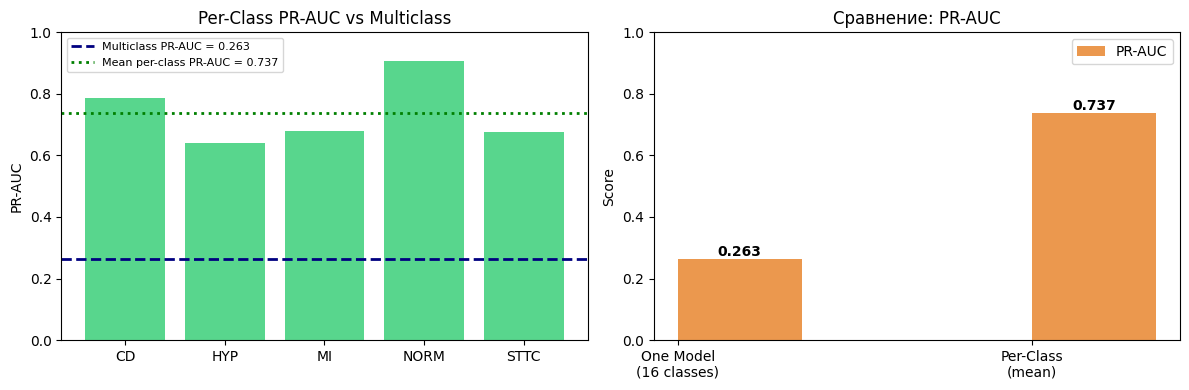

In [12]:
# визуализация подходов 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PR-AUC на класс
pr_vals  = [per_class_results[class_name]['PR-AUC'] for class_name in SUPERCLASSES]
colors2  = ['#2ecc71' if v >= auc_val_multi["PR_AUC"] else '#e74c3c' for v in pr_vals]
axes[0].bar(SUPERCLASSES, pr_vals, color=colors2, alpha=0.8)

axes[0].axhline(
    auc_val_multi['PR_AUC'],
    color='navy',
    linestyle='--',
    linewidth=2,
    label=f'Multiclass PR-AUC = {auc_val_multi["PR_AUC"]:.3f}'
)

axes[0].axhline(
    mean_pr_auc_class,
    color='green',
    linestyle=':',
    linewidth=2,
    label=f'Mean per-class PR-AUC = {mean_pr_auc_class:.3f}'
)

axes[0].set_title('Per-Class PR-AUC vs Multiclass')
axes[0].set_ylabel('PR-AUC')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

# cравнение подходов
x = np.arange(2)
width = 0.35
approaches_labels = ['One Model\n(16 classes)', 'Per-Class\n(mean)']
pr_compare  = [auc_val_multi["PR_AUC"], mean_pr_auc_class]

axes[1].bar(x + width/2, pr_compare, width, label='PR-AUC',    color='#e67e22', alpha=0.8)
for i, p in enumerate(pr_compare):
    axes[1].text(i + width/2, p + 0.01, f'{p:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(approaches_labels)
axes[1].set_title('Сравнение: PR-AUC')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

- Эксперименты показывают, что обучать модель на класс действительно лучше

## 5. Feature Selection

Используем важность признаков CatBoost (PredictionValuesChange) для отбора:
1. Обучаем CatBoost на всех признаках
2. Получаем важность каждого признака
3. Оцениваем по кросс-валидации с разными порогами отсечения
4. Выбираем порог, при котором F1-macro максимальна

**Логика**: признаки с нулевой или пренебрежимо малой важностью — это шум, который снижает обобщение.

In [13]:
importance_df = pd.DataFrame(index=ALL_FEATURE_COLS)
for sc in SUPERCLASSES:
    imp = per_class_models[sc].get_feature_importance()
    importance_df[sc] = imp

importance_df['mean_importance'] = importance_df[SUPERCLASSES].mean(axis=1)
importance_df = importance_df.sort_values('mean_importance', ascending=False)
importance_df.head(10)

,CD,HYP,MI,NORM,STTC,mean_importance
age,2.821035,5.629367,6.175120,7.541633,9.799750,6.393381
lead2_skew,16.201488,0.529096,0.299044,3.365656,0.480832,4.175223
lead12_hf2_energy,0.270892,6.603268,0.492606,4.647424,3.016526,3.006143
lead7_skew,7.826943,0.930911,0.589644,1.605089,1.720436,2.534605
lead4_median,0.819645,0.522448,1.892412,3.766478,4.641169,2.328430
lead10_dom_freq,0.000000,0.276500,0.049010,1.427491,6.710736,1.692747
lead4_skew,2.317006,1.333970,0.547170,1.258022,2.940180,1.679270
lead7_spec_entropy,4.285727,0.629049,1.215490,1.107028,1.053219,1.658103
corr_V2_V6,0.308682,2.326851,0.962955,1.729015,2.911592,1.647819
lead7_hf2_energy,1.201954,1.155754,1.289041,3.825424,0.453863,1.585207


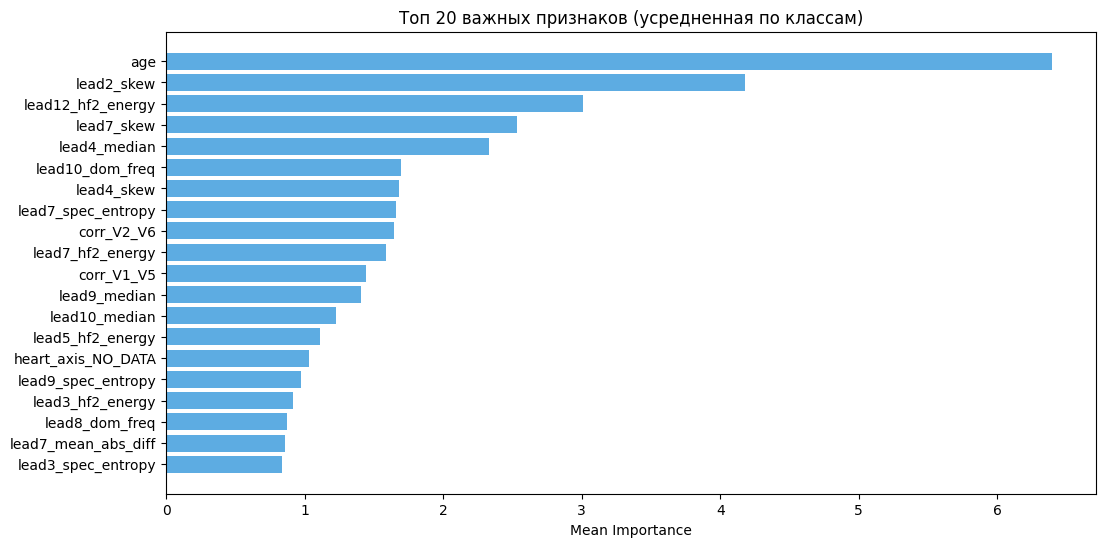

In [14]:
# визуализация важности признаков (топ-K)
k = 20
importance_top_k_df = importance_df['mean_importance'].head(k)

fig, axes = plt.subplots(1, 1, figsize=(12, 6))

axes.barh(
    importance_top_k_df.index[::-1],
    importance_top_k_df.values[::-1],
    color='#3498db',
    alpha=0.8
)
axes.set_title(f'Топ {k} важных признаков (усредненная по классам)')
axes.set_xlabel('Mean Importance');

- Такая важность могла получится случайно, отберем признаки используй метод - "Permutation Importance"

### 5.2 Permutation Importance

- **Идея**: случайно перемешиваем значения признака и измеряем, насколько упала метрика (PR-AUC)
- Если признак важен — метрика сильно падает. Если признак — шум — метрика почти не меняется

Преимущество перед встроенной важностью CatBoost:
- Не зависит от структуры дерева
- Измеряет реальный вклад признака в предсказательную силу
- Нечувствителен к корреляциям между признаками (показывает "истинную" важность)

Реализация через _sklearn.inspection.permutation_importance_:
- Оцениваем на **валидационной** выборке (X_val / y_val)
- Метрика: PR-AUC (Average Precision)
- `n_repeats=15` — количество случайных перемешиваний для надёжной оценки

In [ ]:
!pip install -U scikit-learn

In [15]:
prauc_scorer = make_scorer(
    average_precision_score,
    response_method='predict_proba',
    pos_label=1
)

X_val_arr = X_val[ALL_FEATURE_COLS].values      
feature_names = ALL_FEATURE_COLS

perm_imp_per_class = {}

for class_name in SUPERCLASSES:
    model = per_class_models[class_name]
    y_val_sc = y_val_per_class[class_name].values

    result = permutation_importance(
        model,
        X_val_arr,
        y_val_sc,
        scoring=prauc_scorer,
        n_repeats=10,
        random_state=SEED,
        n_jobs=-1
    )

    perm_imp_per_class[class_name] = {
        'importances_mean': result.importances_mean,
        'importances_std':  result.importances_std,
    }
    print(f'{class_name} done')

CD done
HYP done
MI done
NORM done
STTC done


In [16]:
# так как мы строим модль на класс, то усредним важность по всем классам
perm_imp_df = pd.DataFrame(index=feature_names)

for class_name in SUPERCLASSES:
    perm_imp_df[f'perm_mean_{class_name}'] = perm_imp_per_class[class_name]['importances_mean']
    perm_imp_df[f'perm_std_{class_name}']  = perm_imp_per_class[class_name]['importances_std']

perm_imp_df['perm_mean_global'] = perm_imp_df[[f'perm_mean_{class_name}' for class_name in SUPERCLASSES]].mean(axis=1)
perm_imp_df['perm_std_global']  = perm_imp_df[[f'perm_std_{class_name}'  for class_name in SUPERCLASSES]].mean(axis=1)
perm_imp_df = perm_imp_df.sort_values('perm_mean_global', ascending=False)

print(
    f'Признаков с отрицательной важностью (шум): '
    f'{(perm_imp_df["perm_mean_global"] < 0).sum()}'
)

print(
    f'Признаков с нулевой важностью: '
    f'{(perm_imp_df["perm_mean_global"] == 0).sum()}'
)

Признаков с отрицательной важностью (шум): 125
Признаков с нулевой важностью: 71


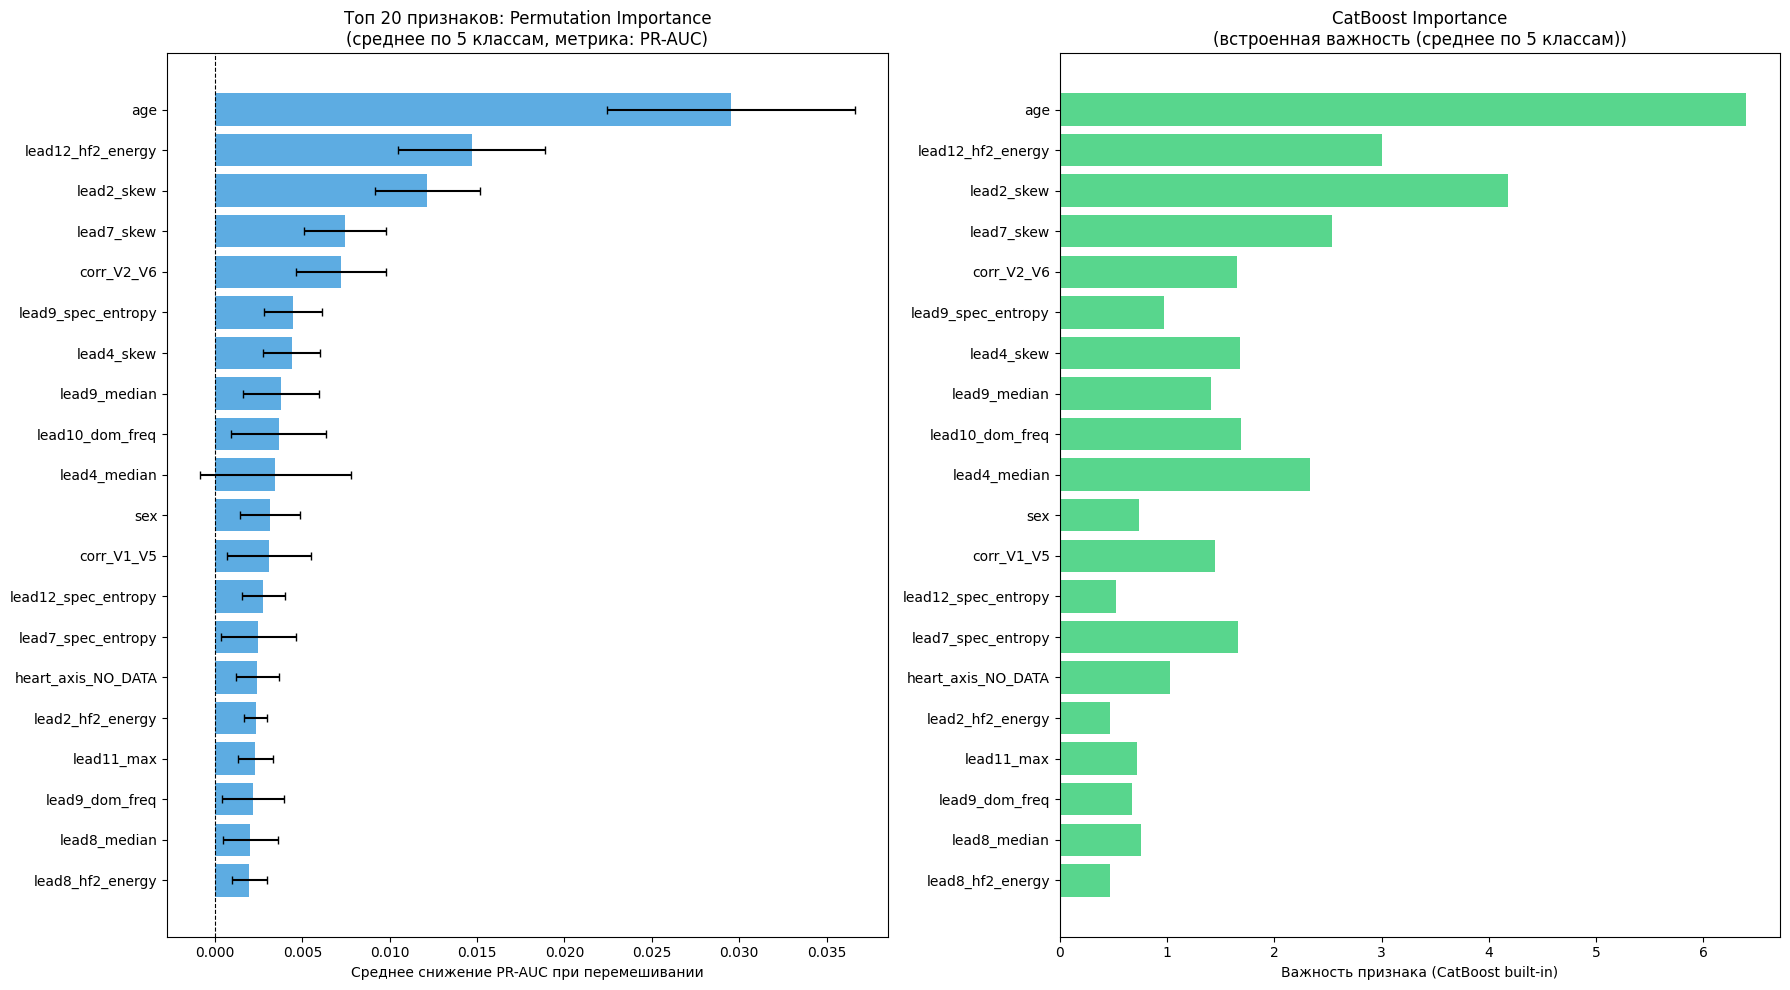

In [17]:
# --- Визуализация: топ-k по Permutation Importance vs CatBoost Importance ---
top_perm = perm_imp_df.head(k)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Permutation Importance (с error bars = std)
perm_means = top_perm['perm_mean_global'].values[::-1]
perm_stds  = top_perm['perm_std_global'].values[::-1]
feat_labels = top_perm.index[::-1]

colors_perm = ['#e74c3c' if v < 0 else '#3498db' for v in perm_means]
axes[0].barh(
    feat_labels, perm_means, xerr=perm_stds, color=colors_perm, alpha=0.8, capsize=3
)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title(f'Топ {k} признаков: Permutation Importance\n(среднее по 5 классам, метрика: PR-AUC)')
axes[0].set_xlabel('Среднее снижение PR-AUC при перемешивании')

# CatBoost Importance (встроенная важность) 
top_builtin = importance_df['mean_importance'].reindex(top_perm.index).fillna(0).values[::-1]
colors_builtin = ['#2ecc71'] * len(top_builtin)
axes[1].barh(feat_labels, top_builtin, color=colors_builtin, alpha=0.8)
axes[1].set_title(f'CatBoost Importance\n(встроенная важность (среднее по 5 классам))')
axes[1].set_xlabel('Важность признака (CatBoost built-in)')

plt.tight_layout()
plt.show()

- Как видно, порядок важности признаков различается! 
- Можно использовать различные комбинации отбора признаков (топ-10, топ-20, ...), мы же просто возьмем все признаки которые имеют ненулевую важность по Feature Importance

In [18]:
# важности признаков - Permutation Importance
columns = [
    'perm_mean_global',
    'perm_std_global'
]

# отберем толко те признаки, которые не имеют нулевую или отрицательную важность (т.е. реально влияют на качество модели)
perm_imp_df_filtered = (
    perm_imp_df[columns]
        .sort_values('perm_mean_global', ascending=False)
)

perm_imp_df_filtered = perm_imp_df_filtered[perm_imp_df_filtered['perm_mean_global'] > 0]
perm_imp_df_filtered

,perm_mean_global,perm_std_global
age,0.029536,0.007076
lead12_hf2_energy,0.014679,0.004232
lead2_skew,0.012152,0.003012
lead7_skew,0.007429,0.002356
corr_V2_V6,0.007204,0.002570
...,...,...
lead6_p25,0.000020,0.000404
lead10_max,0.000011,0.000740
lead1_std_diff,0.000011,0.000118
lead3_mean,0.000009,0.000303


In [19]:
# снова обучим модель на отобранных признаках и проверим качество на валидации
SELECTED_FEATURES = perm_imp_df_filtered.index.tolist()

per_class_results = {}
per_class_models  = {}

for class_name in SUPERCLASSES:
    y_train_class = y_train_per_class[class_name]
    y_val_class = y_val_per_class[class_name]

    # считаем "scale_pos_weight" для баланса
    n_neg = (y_train_class == 0).sum()
    n_pos = (y_train_class == 1).sum()

    eval_pool_bin = Pool(X_val[SELECTED_FEATURES], y_val_class)

    cat_bin = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='PRAUC',
        iterations=500,
        depth=6,
        learning_rate=0.1,
        scale_pos_weight=n_neg / n_pos,  # балансировка классов
        od_type='Iter',                  # OverfittingDetector
        od_wait=30,                      # 30 итераций без улучшения PRAUC на val
        use_best_model=True,
        random_seed=SEED,
        verbose=50
    )

    cat_bin.fit(X_train[SELECTED_FEATURES], y_train_class, eval_set=eval_pool_bin)

    # оценка качества на валидации
    y_val_class_pred = cat_bin.predict(X_val[SELECTED_FEATURES]).flatten()

    f1_macro = f1_score(y_val_class, y_val_class_pred, average='macro', zero_division=0)
    auc_val_class = get_auc(cat_bin, X_val[SELECTED_FEATURES], y_val_class)
    roc_auc_val_class = auc_val_class['ROC_AUC']
    pr_auc_val_class = auc_val_class['PR_AUC']

    per_class_results[class_name] = {
        'F1-macro': f1_macro,
        'PR-AUC': pr_auc_val_class,
        'ROC-AUC': roc_auc_val_class,
        'n_pos_train': n_pos,
        'best_iter': cat_bin.best_iteration_,
    }
    per_class_models[class_name] = cat_bin

mean_f1_macro_class = np.mean([v['F1-macro'] for v in per_class_results.values()])
mean_pr_auc_class = np.mean([v['PR-AUC'] for v in per_class_results.values()])
mean_roc_auc_class = np.mean([v['ROC-AUC'] for v in per_class_results.values()])

print(f'\nMean F1-macro (Модель на класс): {mean_f1_macro_class:.4f}')
print(f'Mean PR-AUC (Модель на класс): {mean_pr_auc_class:.4f}')
print(f'Mean ROC-AUC (Модель на класс): {mean_roc_auc_class:.4f}')

0:	learn: 0.8726651	test: 0.8791536	best: 0.8791536 (0)	total: 17.2ms	remaining: 8.56s
50:	learn: 0.9509880	test: 0.9118423	best: 0.9121761 (34)	total: 760ms	remaining: 6.69s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.9121760988
bestIteration = 34

Shrink model to first 35 iterations.
0:	learn: 0.8347481	test: 0.8088388	best: 0.8088388 (0)	total: 13.1ms	remaining: 6.54s
50:	learn: 0.9467712	test: 0.8862796	best: 0.8870684 (44)	total: 610ms	remaining: 5.37s
100:	learn: 0.9741583	test: 0.8917620	best: 0.8917620 (100)	total: 1.23s	remaining: 4.86s
150:	learn: 0.9919231	test: 0.8950194	best: 0.8955725 (140)	total: 1.82s	remaining: 4.22s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.895572459
bestIteration = 140

Shrink model to first 141 iterations.
0:	learn: 0.7595810	test: 0.7482634	best: 0.7482634 (0)	total: 11.8ms	remaining: 5.89s
50:	learn: 0.8989984	test: 0.8502955	best: 0.8502955 (50)	total: 639ms	remaining: 5.63s
100:	learn: 0.9387077	

- Отбор признаков слегка улучшил качество модели по метрике `PR-AUC (Macro)`
    - Все признаки: 0.7374
    - После отбора (Permutation Importance): 0.7449

- Качество можно попробовать улучшить и дальше, используя более хитрые способы отбора признаков, но для начала это хороший бейзлайн

## 6. Подбор гиперпараметров с Optuna + Cross-Validation

Оптимизируем **общую** функцию: среднее macro-F1 по 5 бинарным классификаторам.

Подбираемые гиперпараметры:
- `depth` — глубина деревьев
- `learning_rate` — скорость обучения
- `l2_leaf_reg` — L2-регуляризация
- `bagging_temperature` — степень случайности бэггинга
- `random_strength` — случайная регуляризация
- `border_count` — число разбиений для числовых признаков
- `scale_pos_weight` — **отдельно оптимизируется для каждого класса** (соотношение neg/pos)

Кросс-валидация: StratifiedKFold, 5 фолдов.

In [20]:
from sklearn.metrics import average_precision_score

X_sel_train = df_train[SELECTED_FEATURES].values
X_sel_test = df_test[SELECTED_FEATURES].values

N_OPTUNA_TRIALS = 3 # для демонстрации (можно увеличить для более тщательного поиска, но это займет больше времени)
N_CV_FOLDS = 3

def objective(trial):
    # все гиперпараметры сэмплируются ОДИН раз на trial (до fold loop)
    params = {
        'loss_function':       'Logloss',
        'iterations':          trial.suggest_int('iterations', 200, 800),
        'depth':               trial.suggest_int('depth', 4, 10),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 0.1, 20.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 2.0),
        'random_strength':     trial.suggest_float('random_strength', 0.1, 10.0, log=True),
        'border_count':        trial.suggest_int('border_count', 32, 255),
        'od_type':             'Iter',
        'od_wait':             30,
        'use_best_model':      True,
        'random_seed':         SEED,
        'verbose':             0,
    }
    # spw_factor для каждого класса сэмплируется один раз, до fold-цикла
    spw_factors = {sc: trial.suggest_float(f'spw_factor_{sc}', 0.5, 3.0) for sc in SUPERCLASSES}

    skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=SEED)
    y_strat = y_train_per_class['NORM'].values

    fold_scores = []
    for train_idx, val_idx in skf.split(X_sel_train, y_strat):
        X_tr_f, X_val_f = X_sel_train[train_idx], X_sel_train[val_idx]

        sc_pr_aucs = []
        for sc in SUPERCLASSES:
            y_sc = y_train_per_class[sc].values
            y_tr_f, y_val_f = y_sc[train_idx], y_sc[val_idx]

            n_neg = (y_tr_f == 0).sum()
            n_pos = (y_tr_f == 1).sum() + 1
            spw = (n_neg / n_pos) * spw_factors[sc]

            cb = CatBoostClassifier(**params, scale_pos_weight=spw)
            # eval_set необходим для работы OverfittingDetector и use_best_model
            cb.fit(X_tr_f, y_tr_f, eval_set=(X_val_f, y_val_f))

            y_proba = cb.predict_proba(X_val_f)[:, 1]
            sc_pr_aucs.append(average_precision_score(y_val_f, y_proba))

        fold_scores.append(np.mean(sc_pr_aucs))

    return np.mean(fold_scores)

In [21]:
# запускам поиск гиперпараметров с Optuna
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)
)

study.optimize(
    objective,
    n_trials=N_OPTUNA_TRIALS,
    show_progress_bar=True
)

print(f'\nBest trial:')
print(f'Value (mean PR-AUC CV): {study.best_value:.4f}')
print(f'Params: {study.best_params}')

Best trial: 1. Best value: 0.737584: 100%|██████████| 3/3 [03:46<00:00, 75.56s/it]


Best trial:
Value (mean PR-AUC CV): 0.7376
Params: {'iterations': 700, 'depth': 5, 'learning_rate': 0.01855998084649059, 'l2_leaf_reg': 0.26425260575499165, 'bagging_temperature': 0.6084844859190754, 'random_strength': 1.1207606211860568, 'border_count': 128, 'spw_factor_CD': 1.2280728504951048, 'spw_factor_HYP': 2.0296322368059485, 'spw_factor_MI': 0.8487346516301046, 'spw_factor_NORM': 1.2303616213380453, 'spw_factor_STTC': 1.4159046082342293}


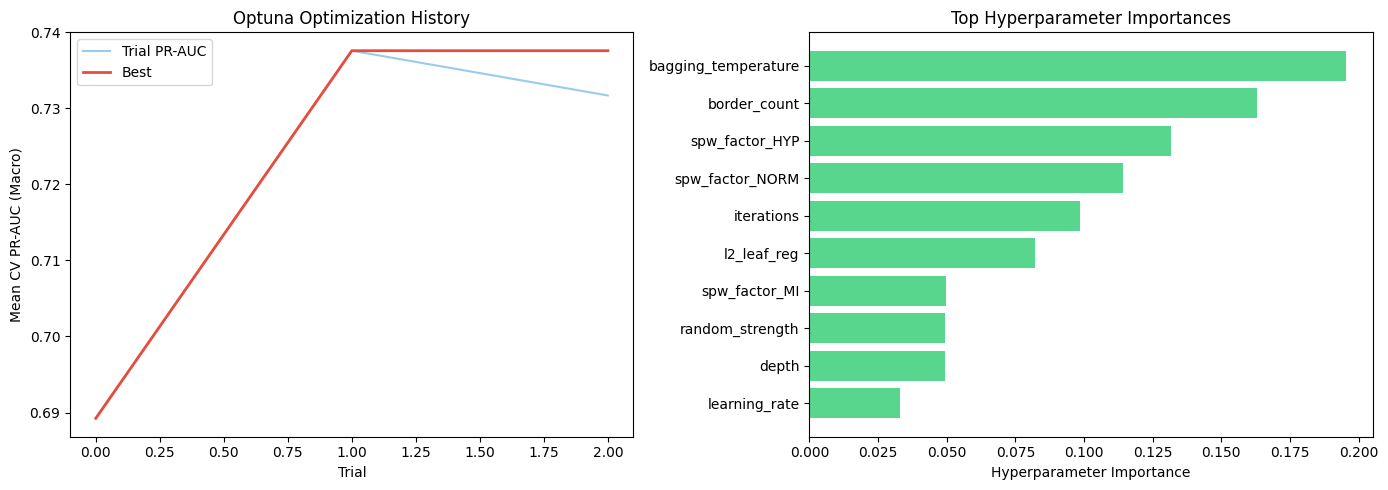

In [22]:
# Анализ Optuna: история оптимизации
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = np.maximum.accumulate(trial_values)
axes[0].plot(trial_values, alpha=0.5, color='#3498db', label='Trial PR-AUC')
axes[0].plot(best_so_far,  color='#e74c3c', linewidth=2, label='Best')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Mean CV PR-AUC (Macro)')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()

# Param importances
try:
    importances = optuna.importance.get_param_importances(study)
    imp_names   = list(importances.keys())[:10]
    imp_values  = [importances[k] for k in imp_names]
    axes[1].barh(imp_names[::-1], imp_values[::-1], color='#2ecc71', alpha=0.8)
    axes[1].set_xlabel('Hyperparameter Importance')
    axes[1].set_title('Top Hyperparameter Importances')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Cannot compute:\n{e}', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

## 7. Финальное обучение на всем train + оценка на test

Обучаем 5 бинарных CatBoost с лучшими гиперпараметрами (из Optuna) на полном train наборе,
оцениваем на отложенном test.

In [23]:
# берем лучшие параметры из Optuna и обучаем финальную модель на всех данных (train + val) с этими параметрами, а затем оцениваем на тесте
best_params = study.best_params.copy()
spw_factors = {sc: best_params.pop(f'spw_factor_{sc}', 1.0) for sc in SUPERCLASSES}

# базовые параметры модели
base_model_params = {
    'loss_function': 'Logloss',
    'eval_metric':   'PRAUC',
    'random_seed':   SEED,
    'verbose':       0,
    **best_params
}

final_models  = {}
final_results = {}

# объединяем train + val для финального обучения
X_sel_val = df_val[SELECTED_FEATURES].values
X_sel_combined = np.vstack([X_sel_train, X_sel_val])

for class_name in SUPERCLASSES:
    y_tr = y_train_per_class[class_name].values
    y_va = y_val_per_class[class_name].values
    y_combined = np.concatenate([y_tr, y_va])

    n_neg = (y_combined == 0).sum()
    n_pos = (y_combined == 1).sum() + 1
    spw = (n_neg / n_pos) * spw_factors[class_name]

    cat_bin = CatBoostClassifier(**base_model_params, scale_pos_weight=spw)
    cat_bin.fit(X_sel_combined, y_combined)

    # оценка качества на test
    y_test_class = y_test_per_class[class_name].values
    y_test_pred = cat_bin.predict(X_sel_test).flatten()

    f1_macro = f1_score(y_test_class, y_test_pred, average='macro', zero_division=0)
    auc_test = get_auc(cat_bin, X_sel_test, y_test_class)

    final_results[class_name] = {
        'F1-macro': f1_macro,
        'PR-AUC':   auc_test['PR_AUC'],
        'ROC-AUC':  auc_test['ROC_AUC'],
    }
    final_models[class_name] = cat_bin
    print(f'{class_name}: F1-macro={f1_macro:.4f}, PR-AUC={auc_test["PR_AUC"]:.4f}')

mean_f1_macro = np.mean([v['F1-macro'] for v in final_results.values()])
mean_pr_auc = np.mean([v['PR-AUC']   for v in final_results.values()])
mean_roc_auc = np.mean([v['ROC-AUC']  for v in final_results.values()])


CD: F1-macro=0.7984, PR-AUC=0.7846
HYP: F1-macro=0.6936, PR-AUC=0.6208
MI: F1-macro=0.7462, PR-AUC=0.6958
NORM: F1-macro=0.8341, PR-AUC=0.8954
STTC: F1-macro=0.7447, PR-AUC=0.7107


In [24]:
results_final_df = pd.DataFrame(final_results).T.round(4)
results_final_df

,F1-macro,PR-AUC,ROC-AUC
CD,0.7984,0.7846,0.8973
HYP,0.6936,0.6208,0.8853
MI,0.7462,0.6958,0.8601
NORM,0.8341,0.8954,0.9224
STTC,0.7447,0.7107,0.8887



Mean F1-macro (Финальная модель | Test): 0.7634
Mean PR-AUC   (Финальная модель | Test): 0.7414
Mean ROC-AUC  (Финальная модель | Test): 0.8908


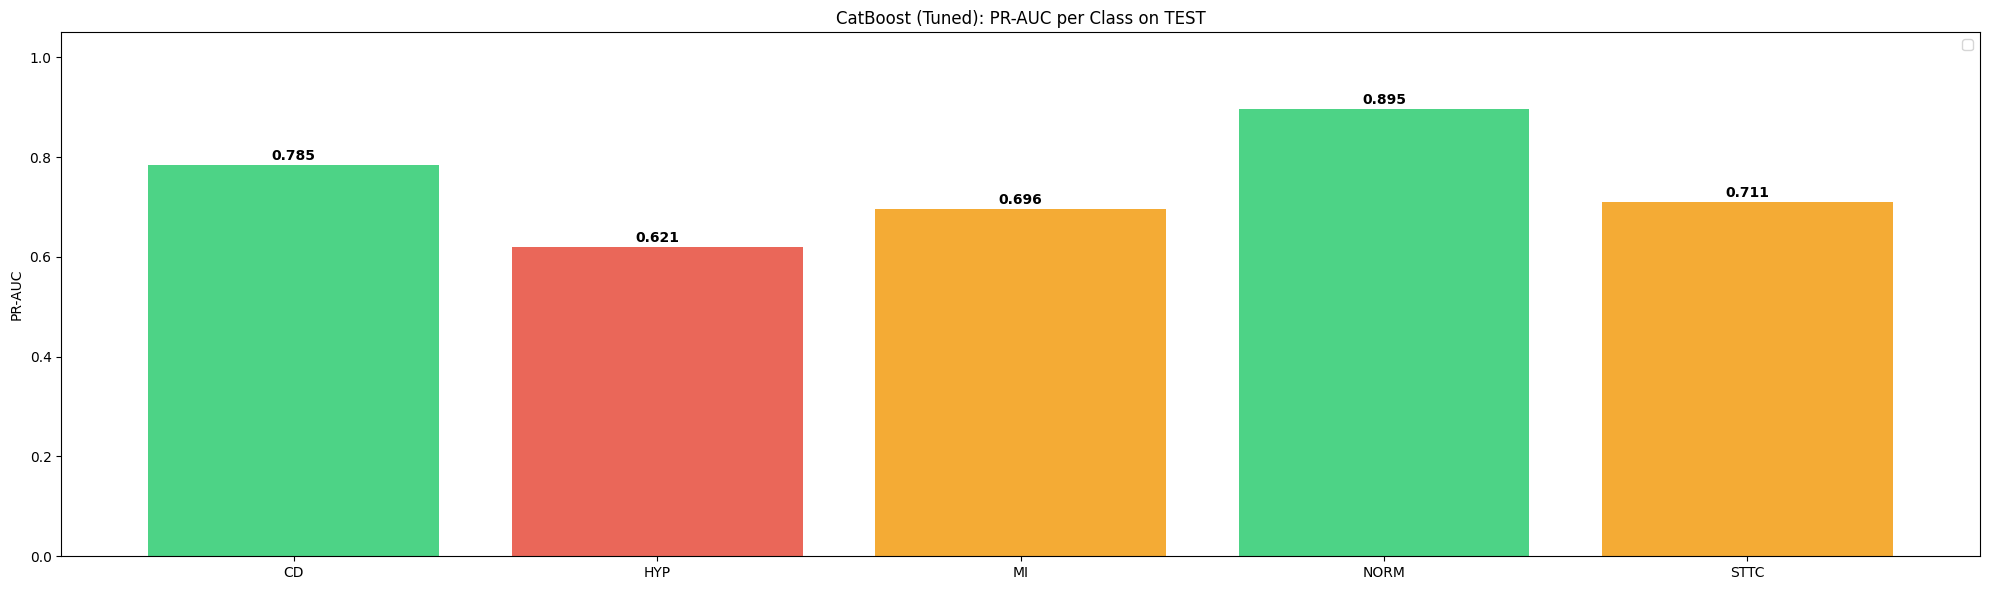

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(20, 6))

# PR-AUC per class
pr_aucs = [final_results[sc]['PR-AUC'] for sc in SUPERCLASSES]

print(f'\nMean F1-macro (Финальная модель | Test): {mean_f1_macro:.4f}')
print(f'Mean PR-AUC   (Финальная модель | Test): {mean_pr_auc:.4f}')
print(f'Mean ROC-AUC  (Финальная модель | Test): {mean_roc_auc:.4f}')

bars = ax.bar(
    SUPERCLASSES,
    pr_aucs,
    color=['#2ecc71' if v >= 0.75 else '#f39c12' if v >= 0.65 else '#e74c3c' for v in pr_aucs],
    alpha=0.85
)

for bar, val in zip(bars, pr_aucs):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.01,
        f'{val:.3f}',
        ha='center',
        fontweight='bold'
    )

ax.set_ylim(0, 1.05)
ax.set_ylabel('PR-AUC')
ax.set_title('CatBoost (Tuned): PR-AUC per Class on TEST')
ax.legend()

plt.tight_layout()
plt.show()

## 8. Сравнение CatBoost с базовой моделью LinearSVC

Переобучаем LinearSVC (OvR) на тех же признаках и данных что и CatBoost. Сравниваем результаты на test. Воссоздаем базовую модель LinearSVC на тех же данных (per-class, selected features)

In [26]:
baseline_results = {}

for sc in SUPERCLASSES:
    y_tr = y_train_per_class[sc].values
    y_te = y_test_per_class[sc].values

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', CalibratedClassifierCV(
            LinearSVC(class_weight='balanced', random_state=SEED, max_iter=3000),
            cv=3
        ))
    ])
    pipe.fit(X_sel_train, y_tr)
    y_pred  = pipe.predict(X_sel_test)
    y_proba = pipe.predict_proba(X_sel_test)[:, 1]

    baseline_results[sc] = {
        'F1-macro':    f1_score(y_te, y_pred, average='macro', zero_division=0),
        'PR-AUC':      average_precision_score(y_te, y_proba),
    }
    print(f'  {sc}: F1-macro={baseline_results[sc]["F1-macro"]:.4f}, PR-AUC={baseline_results[sc]["PR-AUC"]:.4f}')

baseline_mean_f1    = np.mean([v['F1-macro'] for v in baseline_results.values()])
baseline_mean_prauc = np.mean([v['PR-AUC']   for v in baseline_results.values()])
print(f'\nLinearSVC mean F1-macro: {baseline_mean_f1:.4f}')
print(f'LinearSVC mean PR-AUC:   {baseline_mean_prauc:.4f}')

# Также берём результаты из ecg_linear_models.ipynb (оригинальные, без feature selection)
original_linear_svc = {
    'CD':   0.777,
    'HYP':  0.708,
    'MI':   0.730,
    'NORM': 0.806,  # из ecg_linear_models.ipynb
    'STTC': 0.744,
}
original_mean = np.mean(list(original_linear_svc.values()))
print(f'Original LinearSVC (from ecg_linear_models.ipynb) mean F1-macro: {original_mean:.4f}')

  CD: F1-macro=0.7999, PR-AUC=0.7580
  HYP: F1-macro=0.6809, PR-AUC=0.5504
  MI: F1-macro=0.6692, PR-AUC=0.6155
  NORM: F1-macro=0.8252, PR-AUC=0.8808
  STTC: F1-macro=0.7303, PR-AUC=0.6732

LinearSVC mean F1-macro: 0.7411
LinearSVC mean PR-AUC:   0.6956
Original LinearSVC (from ecg_linear_models.ipynb) mean F1-macro: 0.7530


In [27]:
# итоговая сравнительная таблица (F1-macro)
comparison_rows = []
for sc in SUPERCLASSES:
    comparison_rows.append({
        'Superclass':                    sc,
        'LinearSVC (original)':          original_linear_svc[sc],
        'LinearSVC (same features)':     round(baseline_results[sc]['F1-macro'], 4),
        'CatBoost (default, all feats)': round(per_class_results[sc]['F1-macro'], 4),
        'CatBoost (tuned, sel feats)':   round(final_results[sc]['F1-macro'], 4),
    })

comparison_rows.append({
    'Superclass':                    'MEAN',
    'LinearSVC (original)':          round(original_mean, 4),
    'LinearSVC (same features)':     round(baseline_mean_f1, 4),
    'CatBoost (default, all feats)': round(mean_f1_macro_class, 4),
    'CatBoost (tuned, sel feats)':   round(mean_f1_macro, 4),
})

comparison_df = pd.DataFrame(comparison_rows).set_index('Superclass')

print('MODEL COMPARISON (F1-macro on TEST)')
print(comparison_df.to_string())

# PR-AUC comparison table (LinearSVC original has no probabilities -> N/A)
prauc_rows = []
for sc in SUPERCLASSES:
    prauc_rows.append({
        'Superclass':                    sc,
        'LinearSVC (same features)':     round(baseline_results[sc]['PR-AUC'], 4),
        'CatBoost (default, all feats)': round(per_class_results[sc]['PR-AUC'], 4),
        'CatBoost (tuned, sel feats)':   round(final_results[sc]['PR-AUC'], 4),
    })

prauc_rows.append({
    'Superclass':                    'MEAN',
    'LinearSVC (same features)':     round(baseline_mean_prauc, 4),
    'CatBoost (default, all feats)': round(mean_pr_auc_class, 4),
    'CatBoost (tuned, sel feats)':   round(mean_pr_auc, 4),
})

prauc_df = pd.DataFrame(prauc_rows).set_index('Superclass')

print('\nMODEL COMPARISON (PR-AUC on TEST)')
print(prauc_df.to_string())

# Подсчет улучшений (F1-macro)
mean_row = comparison_df.loc['MEAN']
delta_default = mean_row['CatBoost (default, all feats)'] - mean_row['LinearSVC (original)']
delta_tuned   = mean_row['CatBoost (tuned, sel feats)']   - mean_row['LinearSVC (original)']
delta_tuned_vs_default = mean_row['CatBoost (tuned, sel feats)'] - mean_row['CatBoost (default, all feats)']

print(f'\nDELTA vs Original LinearSVC (F1-macro)')
print(f'CatBoost Default (all feats) vs LinearSVC original: {delta_default:+.4f}')
print(f'CatBoost Tuned  (sel feats)  vs LinearSVC original: {delta_tuned:+.4f}')
print(f'CatBoost Tuned  vs CatBoost Default:                {delta_tuned_vs_default:+.4f}')

# PR-AUC improvement (CatBoost tuned vs LinearSVC same features)
prauc_mean_row = prauc_df.loc['MEAN']
delta_prauc = prauc_mean_row['CatBoost (tuned, sel feats)'] - prauc_mean_row['LinearSVC (same features)']
print(f'\nCatBoost Tuned vs LinearSVC (PR-AUC)')
print(f'PR-AUC improvement: {delta_prauc:+.4f}')

MODEL COMPARISON (F1-macro on TEST)
            LinearSVC (original)  LinearSVC (same features)  CatBoost (default, all feats)  CatBoost (tuned, sel feats)
Superclass                                                                                                             
CD                         0.777                     0.7999                         0.7960                       0.7984
HYP                        0.708                     0.6809                         0.7465                       0.6936
MI                         0.730                     0.6692                         0.7400                       0.7462
NORM                       0.806                     0.8252                         0.8333                       0.8341
STTC                       0.744                     0.7303                         0.7601                       0.7447
MEAN                       0.753                     0.7411                         0.7752                       0.7634

MOD

### Ключевые выводы

1. **Отбор признаков работает**: 
    - Permutation Importance позволил отсеять шумовые признаки и улучшить PR-AUC с ~0.737 до ~0.745 на валидации. Модель стала компактнее и точнее.

2. **Per-class подход лучше multiclass**: 
    - Обучение 5 отдельных бинарных классификаторов (по одному на диагностический суперкласс) превзошло единую 16-классовую модель. Это объясняется экстремальным дисбалансом редких комбо-классов.

3. **CatBoost превосходит LinearSVC**: 
    - Градиентный бустинг естественно обрабатывает нелинейные зависимости в ЭКГ-признаках без явной нормализации, что даёт выигрыш по обеим метрикам (F1-macro и PR-AUC).

4. **Подбор гиперпараметров (Optuna) дополнительно улучшает модель**: 
    - Оптимизация `depth`, `learning_rate`, `l2_leaf_reg` и индивидуальных `scale_pos_weight` для каждого класса позволяет лучше балансировать качество на редких положительных примерах.

5. **Обучение на train+val для финальной модели**: 
    - Финальные модели обучались на объединённых данных (фолды 1–8), что даёт больше данных для обучения без риска утечки — тест (фолды 9–10) остаётся полностью изолированным.

### Возможные улучшения

- Увеличить `N_OPTUNA_TRIALS` для более тщательного поиска гиперпараметров (текущее значение слишком мало)
- Попробовать ансамблирование CatBoost + LightGBM
- Добавить еще признаков:
    - Добавить признаки на основе вейвлет-преобразования сигнала
    - Использовать временны́е признаки (длительности интервалов P, QRS, T)


### ML Flow

In [ ]:
import mlflow
import os

os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"
os.environ["AWS_ACCESS_KEY_ID"] = "add_your_key"
os.environ["AWS_SECRET_ACCESS_KEY"] = "add_your_secret"

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("ecg-catboost")

2026/05/31 19:05:41 INFO mlflow.tracking.fluent: Experiment with name 'ecg-catboost' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://mlflow-artifacts/1', creation_time=1780247141538, experiment_id='1', last_update_time=1780247141538, lifecycle_stage='active', name='ecg-catboost', tags={}, trace_location=None, workspace='default'>

In [37]:
with mlflow.start_run(run_name="catboost_tuned_final") as run:

    # логируем гиперпараметры
    mlflow.log_params(best_params)
    mlflow.log_param("seed", SEED)
    mlflow.log_param("n_features", len(SELECTED_FEATURES))
    mlflow.log_param("model_type", "CatBoost_5binary")

    # логируем метрики
    mlflow.log_metric("mean_f1_macro_test", mean_f1_macro)
    mlflow.log_metric("mean_pr_auc_test", mean_pr_auc)
    mlflow.log_metric("mean_roc_auc_test", mean_roc_auc)
    for sc in SUPERCLASSES:
        mlflow.log_metric(f"f1_macro_{sc}", final_results[sc]["F1-macro"])
        mlflow.log_metric(f"pr_auc_{sc}", final_results[sc]["PR-AUC"])

    # сохраняем модели в нативном формате CatBoost
    with tempfile.TemporaryDirectory() as tmp:
        for sc in SUPERCLASSES:
            path = f"{tmp}/catboost_{sc}.cbm"
            final_models[sc].save_model(path)
            mlflow.log_artifact(path, artifact_path="models")

    # сохраняем список признаков
    with tempfile.TemporaryDirectory() as tmp:
        features_path = f"{tmp}/selected_features.txt"
        with open(features_path, "w") as f:
            f.write("\n".join(SELECTED_FEATURES))
        mlflow.log_artifact(features_path, artifact_path="models")

    # логируем графики
    mlflow.log_figure(fig, "pr_auc_per_class.png")

    # ставим тег PRD
    mlflow.set_tag("stage", "PRD")
    mlflow.set_tag("model", "CatBoost_5binary")

🏃 View run catboost_tuned_final at: http://localhost:5000/#/experiments/1/runs/5b4041d9f1b8443f9ecfde10a0a30368
🧪 View experiment at: http://localhost:5000/#/experiments/1
